What are the most demanded skills for the top 3 popular data roles?

Methodology
1. cleanup skill col
2. calculate skill count based on job_title_short
3. calculate skill percentage
4. plot final findings

In [2]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [3]:
#filter for US
df_US = df[df['job_country'] == 'United States']

#explode job_skills 
df_skills = df_US.explode('job_skills')

df_skills[['job_title_short', 'job_skills']]

,job_title_short,job_skills
0,Senior Data Engineer,None
3,Data Engineer,python
3,Data Engineer,c++
3,Data Engineer,java
3,Data Engineer,matlab
...,...,...
785692,Data Scientist,r
785703,Data Analyst,None
785705,Data Analyst,sql
785705,Data Analyst,python


In [4]:
df_skills_count = df_skills.groupby(['job_title_short', 'job_skills']).size()
df_skills_count

job_title_short    job_skills
Business Analyst   airflow        38
                   airtable        3
                   alteryx       264
                   angular        10
                   ansible         3
                                ... 
Software Engineer  wire            2
                   word          106
                   workfront       2
                   yarn            6
                   zoom           16
Length: 1870, dtype: int64

In [5]:
df_skills_count = df_skills_count.reset_index(name='skill_count')

df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)

df_skills_count

,job_title_short,job_skills,skill_count
886,Data Scientist,python,42379
472,Data Analyst,sql,34452
921,Data Scientist,sql,30034
351,Data Analyst,excel,27519
890,Data Scientist,r,26022
...,...,...,...
1313,Senior Data Engineer,asp.net core,1
228,Cloud Engineer,ms access,1
1020,Machine Learning Engineer,graphql,1
1582,Senior Data Scientist,mariadb,1


In [6]:
job_titles = df_skills_count['job_title_short'].unique().tolist()

job_titles = sorted(job_titles[:3])
job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

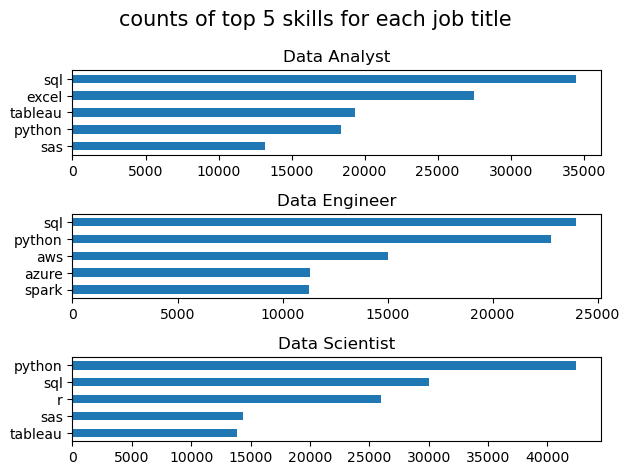

In [11]:
fig, ax = plt.subplots(len(job_titles), 1)  

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)
    df_plot.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[i], title=job_title)                        
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)
fig.suptitle('counts of top 5 skills for each job title', fontsize=15)
fig.tight_layout()    


3. percentage

In [15]:
df_job_title_count = df_US['job_title_short'].value_counts().reset_index(name='jobs_total')
df_job_title_count

,job_title_short,jobs_total
0,Data Analyst,67816
1,Data Scientist,58830
2,Data Engineer,35080
3,Senior Data Scientist,12946
4,Senior Data Analyst,11791
5,Senior Data Engineer,9289
6,Business Analyst,7382
7,Software Engineer,1814
8,Machine Learning Engineer,921
9,Cloud Engineer,423


In [16]:
df_skills_count

,job_title_short,job_skills,skill_count
886,Data Scientist,python,42379
472,Data Analyst,sql,34452
921,Data Scientist,sql,30034
351,Data Analyst,excel,27519
890,Data Scientist,r,26022
...,...,...,...
1313,Senior Data Engineer,asp.net core,1
228,Cloud Engineer,ms access,1
1020,Machine Learning Engineer,graphql,1
1582,Senior Data Scientist,mariadb,1


In [17]:
#merge the two dataframes to get the percentage of each skill for each job title
#left join

df_skills_per = pd.merge(df_skills_count, df_job_title_count, how='left', on='job_title_short')
df_skills_per


,job_title_short,job_skills,skill_count,jobs_total
0,Data Scientist,python,42379,58830
1,Data Analyst,sql,34452,67816
2,Data Scientist,sql,30034,58830
3,Data Analyst,excel,27519,67816
4,Data Scientist,r,26022,58830
...,...,...,...,...
1865,Senior Data Engineer,asp.net core,1,9289
1866,Cloud Engineer,ms access,1,423
1867,Machine Learning Engineer,graphql,1,921
1868,Senior Data Scientist,mariadb,1,12946


In [18]:
#calculate percentage of each skill for each job title
df_skills_per['skill_perc'] = df_skills_per['skill_count']/df_skills_per['jobs_total']*100
df_skills_per

,job_title_short,job_skills,skill_count,jobs_total,skill_perc
0,Data Scientist,python,42379,58830,72.036376
1,Data Analyst,sql,34452,67816,50.802171
2,Data Scientist,sql,30034,58830,51.052184
3,Data Analyst,excel,27519,67816,40.578919
4,Data Scientist,r,26022,58830,44.232534
...,...,...,...,...,...
1865,Senior Data Engineer,asp.net core,1,9289,0.010765
1866,Cloud Engineer,ms access,1,423,0.236407
1867,Machine Learning Engineer,graphql,1,921,0.108578
1868,Senior Data Scientist,mariadb,1,12946,0.007724


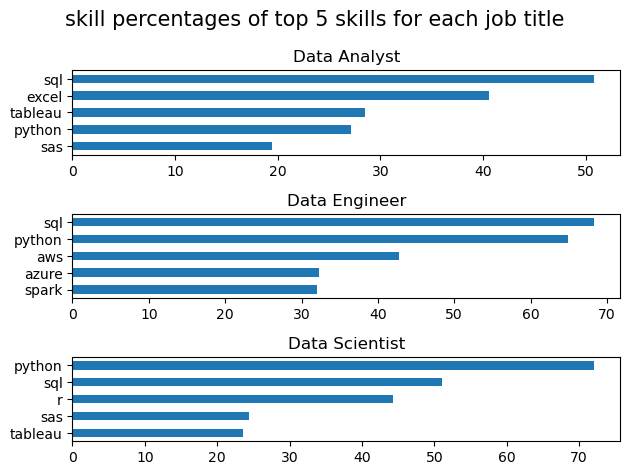

In [20]:
fig, ax = plt.subplots(len(job_titles), 1)  

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_per[df_skills_per['job_title_short'] == job_title].head(5)
    df_plot.plot(kind='barh', x='job_skills', y='skill_perc', ax=ax[i], title=job_title)                        
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)
fig.suptitle('skill percentages of top 5 skills for each job title', fontsize=15)
fig.tight_layout()    


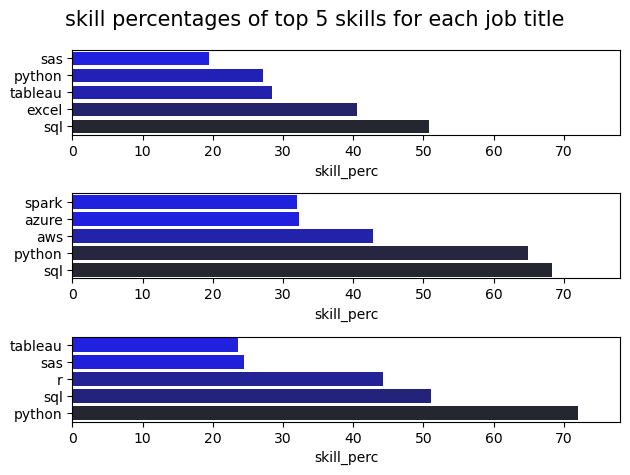

In [ ]:
fig, ax = plt.subplots(len(job_titles), 1)  

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_per[df_skills_per['job_title_short'] == job_title].head(5)
    
    sns.barplot(data=df_plot, x='skill_perc', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    #df_plot.plot(kind='barh', x='job_skills', y='skill_perc', ax=ax[i], title=job_title)                        
    ax[i].invert_yaxis()  #its fn of matplotlib not of seaborn so it will not work here
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False) #ax[i].get_legend().remove()
    ax[i].set_xlim(0,78)
fig.suptitle('skill percentages of top 5 skills for each job title', fontsize=15)
fig.tight_layout()    


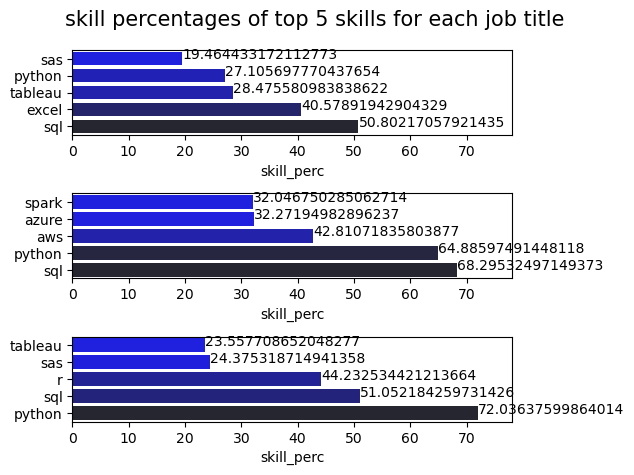

In [ ]:
fig, ax = plt.subplots(len(job_titles), 1)  

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_per[df_skills_per['job_title_short'] == job_title].head(5)
    
    sns.barplot(data=df_plot, x='skill_perc', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    #df_plot.plot(kind='barh', x='job_skills', y='skill_perc', ax=ax[i], title=job_title)                        
    ax[i].invert_yaxis()  #its fn of matplotlib not of seaborn so it will not work here
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False) #ax[i].get_legend().remove()
    ax[i].set_xlim(0,78)
    
    for j, v in enumerate(df_plot['skill_perc']):
        ax[i].text(v, j, v)  #v and j are the coordinates of x and y where we want to add info
        #ax[i].text(x, y, value)  j-index
    
fig.suptitle('skill percentages of top 5 skills for each job title', fontsize=15)
fig.tight_layout()    


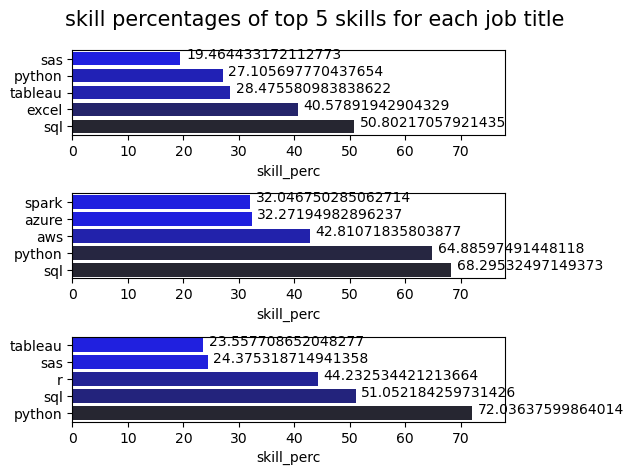

In [34]:
fig, ax = plt.subplots(len(job_titles), 1)  

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_per[df_skills_per['job_title_short'] == job_title].head(5)
    
    sns.barplot(data=df_plot, x='skill_perc', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    #df_plot.plot(kind='barh', x='job_skills', y='skill_perc', ax=ax[i], title=job_title)                        
    ax[i].invert_yaxis()  #its fn of matplotlib not of seaborn so it will not work here
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False) #ax[i].get_legend().remove()
    ax[i].set_xlim(0,78)
    
    for j, v in enumerate(df_plot['skill_perc']):
        ax[i].text(v+1, j, v)  
        #ax[i].text(x, y, value)  j-index
    
fig.suptitle('skill percentages of top 5 skills for each job title', fontsize=15)
fig.tight_layout()    


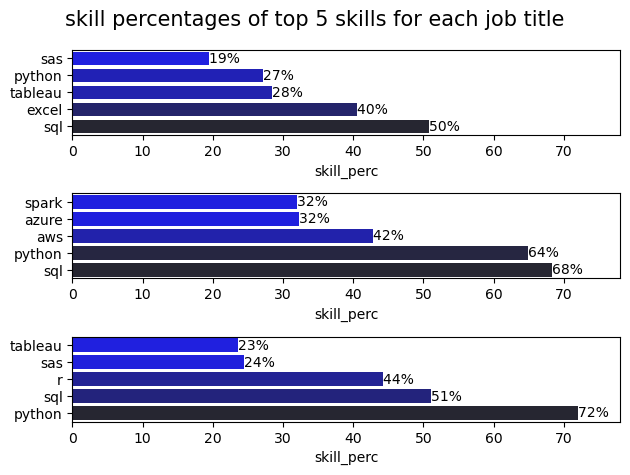

In [40]:
fig, ax = plt.subplots(len(job_titles), 1)  

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_per[df_skills_per['job_title_short'] == job_title].head(5)
    
    sns.barplot(data=df_plot, x='skill_perc', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    #df_plot.plot(kind='barh', x='job_skills', y='skill_perc', ax=ax[i], title=job_title)                        
    ax[i].invert_yaxis()  #its fn of matplotlib not of seaborn so it will not work here
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False) #ax[i].get_legend().remove()
    ax[i].set_xlim(0,78)
    
    for j, v in enumerate(df_plot['skill_perc']):
        ax[i].text(v, j, f'{int(v)}% ', va='center')
        #ax[i].text(x, y, value)  j-index
    
fig.suptitle('skill percentages of top 5 skills for each job title', fontsize=15)
fig.tight_layout()    


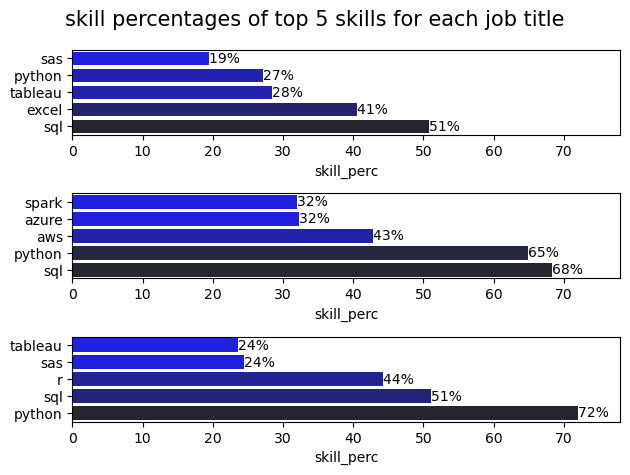

In [41]:
fig, ax = plt.subplots(len(job_titles), 1)  

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_per[df_skills_per['job_title_short'] == job_title].head(5)
    
    sns.barplot(data=df_plot, x='skill_perc', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    #df_plot.plot(kind='barh', x='job_skills', y='skill_perc', ax=ax[i], title=job_title)                        
    ax[i].invert_yaxis()  #its fn of matplotlib not of seaborn so it will not work here
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False) #ax[i].get_legend().remove()
    ax[i].set_xlim(0,78)
    
    for j, v in enumerate(df_plot['skill_perc']):
        ax[i].text(v, j, f'{v:.0f}% ', va='center') #floating point
        #ax[i].text(x, y, value)  j-index
    
fig.suptitle('skill percentages of top 5 skills for each job title', fontsize=15)
fig.tight_layout()    
